<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

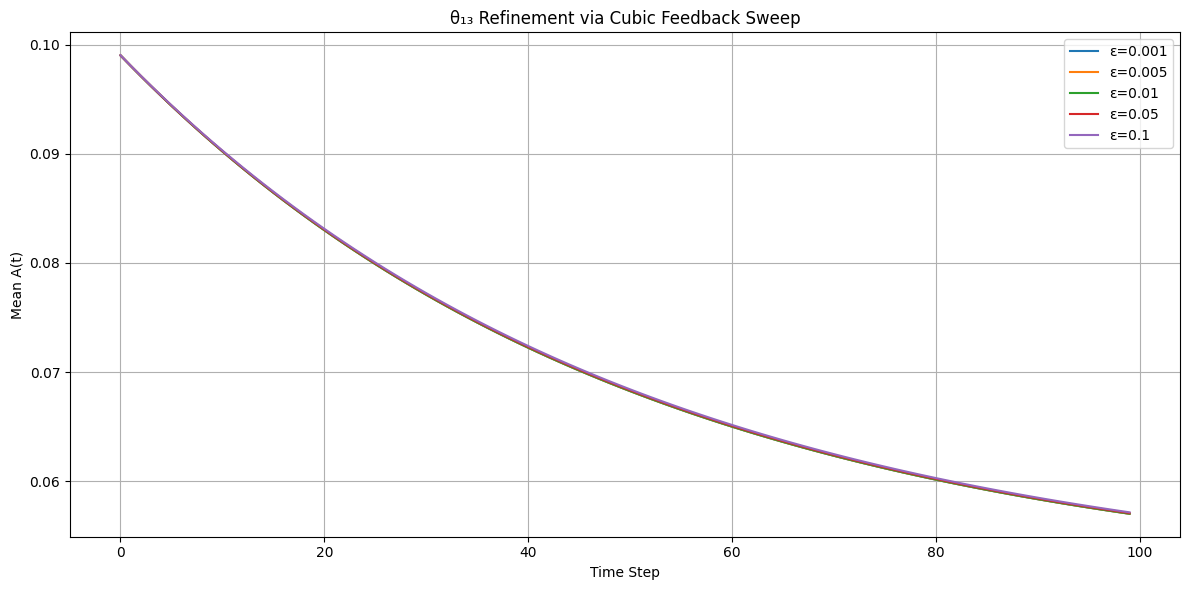

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma0 = 0.5
xi = 0.01
A0 = 0.1
time_steps = 100
grid_size = 50
epsilons = [0.001, 0.005, 0.01, 0.05, 0.1]

# -------------------------------
# Evolution Function
# -------------------------------
def evolve_cubic(epsilon):
    A = np.ones(grid_size) * A0
    history = []
    for t in range(time_steps):
        laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
        dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + xi
        A += dA_dt * 0.1
        history.append(np.mean(A))
    return history

# -------------------------------
# Run Sweep and Plot
# -------------------------------
plt.figure(figsize=(12, 6))
for eps in epsilons:
    result = evolve_cubic(eps)
    plt.plot(result, label=f'ε={eps}')
plt.title("θ₁₃ Refinement via Cubic Feedback Sweep")
plt.xlabel("Time Step")
plt.ylabel("Mean A(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
